# Phrase-Based Statistical Machine Translation (PBSMT): Version 1
## Myanmar (Burmese) Language: Grapheme - Phoneme Translation

## Setup

In [1]:
from pathlib import Path
from IPython.display import Image

In [2]:
ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data" / "cleaned"

TEST_SGM_DIR = DATA_DIR / "test-sgm"

MOSES_DIR = "/home/lawun330/NLP/ubuntu-17.04"
GIZA_DIR = "/home/lawun330/NLP/giza-pp"

## Configurations

In [3]:
# check current path
!pwd

/home/lawun330/Desktop/basic-statistical-machine-translation/notebooks


In [4]:
# check baseline dir before config generation
!tree {ROOT}/baseline

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline  [error opening dir]

0 directories, 0 files


In [5]:
# check edit paths in config.baseline
!cat {ROOT}/config.baseline

### directories that contain tools and data
# 
# moses
moses-src-dir = /home/lawun330/NLP/ubuntu-17.04/moses # -- EDIT HERE --

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
external-bin-dir = /home/lawun330/NLP/giza-pp/GIZA++-v2 # -- EDIT HERE --

# srilm
srilm-dir = /home/lawun330/NLP/SRILM/bin/i686-m64 # -- EDIT HERE --

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm/bin

# kenlm
lmplz = $moses-bin-dir/lmplz

# data
myg2p-data = /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned # -- EDIT HERE --

### basic tools
#
# moses decoder
decoder = $moses-bin-dir/moses

# conversion of phrase table into binary on-disk format
#ttable-binarizer = $moses-bin-dir/processPhraseTable

# conversion of rule table into binary on-disk format
#ttable-binarizer = "$moses-bin-dir/CreateOnDiskPt 1 1 4 100 2"

# tokenizers 

In [6]:
# generate translation-specific config files
!perl {ROOT}/generate_configs.pl

In [7]:
# check baseline dir after config generation
!tree {ROOT}/baseline

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline
├── my-ph
│   └── config.baseline.my-ph
└── ph-my
    └── config.baseline.ph-my

3 directories, 2 files


## Check Files

The source and target language files in a translation pair must contain the same number of lines.

In [8]:
!wc {DATA_DIR}/*

   2000    5687   59210 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/dev.my
   2000    5688   25849 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/dev.ph
   2802    8048   83945 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test.my
   2802    8048   36532 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test.ph
wc: /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm: Is a directory
      0       0       0 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm
  20000   57345  594174 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/train.my
  20000   57346  260356 /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/train.ph
  49604  142162 1060066 total


## Generate SGM Files

These files are necessary when using the Moses SMT tool with a configuration file.

In [9]:
%cd {TEST_SGM_DIR}

/home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/test-sgm


In [10]:
!perl generate_sgms.pl

In [11]:
# verify sgm files
!tree .

.
├── generate_sgms.pl
├── ref2sgm.pl
├── src2sgm.pl
├── test.my.ref.sgm
├── test.my.src.sgm
├── test.ph.ref.sgm
└── test.ph.src.sgm

1 directory, 7 files


## Run 1: Machine Translation

In [12]:
%cd {ROOT}/baseline

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline


In [13]:
# create a dir for logs for run-baseline script
!mkdir logs

In [14]:
!time perl {ROOT}/run-baseline.pl

my-ph-baseline /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/config.baseline.ph-my

real	1m26.726s
user	0m0.424s
sys	0m0.323s


## Run 1: Results

In [15]:
!tree -L 2 .

.
├── logs
│   └── run1.log
├── my-ph
│   ├── config.baseline.my-ph
│   ├── corpus
│   ├── evaluation
│   ├── lm
│   ├── steps
│   └── training
├── ph-my
│   ├── config.baseline.ph-my
│   ├── corpus
│   ├── evaluation
│   ├── lm
│   ├── steps
│   └── training
└── steps

15 directories, 3 files


In [16]:
# read log
!cat logs/run1.log

Unescaped left brace in regex is passed through in regex; marked by <-- HERE in m/^\[([^:]+):{ <-- HERE (\S+)}:(\S+)\]$/ at /home/lawun330/NLP/ubuntu-17.04/moses/scripts/ems/experiment.perl line 626.
STARTING UP AS PROCESS 60563 ON ROG-Strix-Hero-II AT Thu May 21 03:38:18 AM +07 2026
LOAD CONFIG...
working directory is /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph
find: ‘/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps’: No such file or directory
running experimental run number 1

ESTABLISH WHICH STEPS NEED TO BE RUN

FIND DEPENDENCIES BETWEEN STEPS

CHECKING IF OLD STEPS ARE RE-USABLE

STEP SUMMARY:
82 EVALUATION:test:input-from-sgm ->	run
76 CORPUS:myg2p-data:clean ->	run
59 LM:myg2p-data:train ->	run
56 LM:myg2p-data:binarize ->	run
55 TRAINING:consolidate ->	run
54 TRAINING:prepare-data ->	run
53 TRAINING:run-giza ->	run
52 TRAINING:run-giza-inverse ->	run
51 TRAINING:symmetrize-giza ->	run
50 TRAINING:build-lex-trans -

In [17]:
# find error files
!find . -name '*.STDERR'

./ph-my/steps/1/EVALUATION_test_reference-from-sgm.1.STDERR
./ph-my/steps/1/EVALUATION_test_input-from-sgm.1.STDERR
./ph-my/steps/1/LM_myg2p-data_binarize.1.STDERR
./ph-my/steps/1/LM_myg2p-data_train.1.STDERR
./ph-my/steps/1/TRAINING_consolidate.1.STDERR
./ph-my/steps/1/CORPUS_myg2p-data_clean.1.STDERR
./ph-my/steps/1/TRAINING_prepare-data.1.STDERR
./my-ph/steps/1/EVALUATION_test_reference-from-sgm.1.STDERR
./my-ph/steps/1/EVALUATION_test_input-from-sgm.1.STDERR
./my-ph/steps/1/LM_myg2p-data_binarize.1.STDERR
./my-ph/steps/1/LM_myg2p-data_train.1.STDERR
./my-ph/steps/1/TRAINING_consolidate.1.STDERR
./my-ph/steps/1/CORPUS_myg2p-data_clean.1.STDERR
./my-ph/steps/1/TRAINING_prepare-data.1.STDERR


In [18]:
!tail my-ph/steps/1/*.STDERR

==> my-ph/steps/1/CORPUS_myg2p-data_clean.1.STDERR <==
clean-corpus.perl: processing /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/train.my & .ph to /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/corpus/myg2p-data.clean.1, cutoff 1-80, ratio 9
..
Input sentences: 20000  Output sentences:  20000

==> my-ph/steps/1/EVALUATION_test_input-from-sgm.1.STDERR <==

==> my-ph/steps/1/EVALUATION_test_reference-from-sgm.1.STDERR <==

==> my-ph/steps/1/LM_myg2p-data_binarize.1.STDERR <==
Reading /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/lm/myg2p-data.lm.1
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS

==> my-ph/steps/1/LM_myg2p-data_train.1.STDERR <==
trie     410 without quantization
trie     217 assuming -q 8 -b 8 quantization 
trie     376 assu

In [19]:
!tail ph-my/steps/1/*.STDERR

==> ph-my/steps/1/CORPUS_myg2p-data_clean.1.STDERR <==
clean-corpus.perl: processing /home/lawun330/Desktop/basic-statistical-machine-translation/data/cleaned/train.ph & .my to /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/corpus/myg2p-data.clean.1, cutoff 1-80, ratio 9
..
Input sentences: 20000  Output sentences:  20000

==> ph-my/steps/1/EVALUATION_test_input-from-sgm.1.STDERR <==

==> ph-my/steps/1/EVALUATION_test_reference-from-sgm.1.STDERR <==

==> ph-my/steps/1/LM_myg2p-data_binarize.1.STDERR <==
Reading /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/lm/myg2p-data.lm.1
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS

==> ph-my/steps/1/LM_myg2p-data_train.1.STDERR <==
trie     436 without quantization
trie     237 assuming -q 8 -b 8 quantization 
trie     403 assu

## Run 1: Fix
### Add Missing File to GIZA++

The **`giza-pp/GIZA++-v2/`** folder expects the `mkcls` file, which is currently missing. This file is located under **`giza-pp/mkcls-v2/`**.

In [20]:
# verify that the required file is missing before copying
!ls {GIZA_DIR}/GIZA++-v2/mkcls

ls: cannot access '/home/lawun330/NLP/giza-pp/GIZA++-v2/mkcls': No such file or directory


In [21]:
!cp {GIZA_DIR}/mkcls-v2/mkcls {GIZA_DIR}/GIZA++-v2/

In [22]:
# verify the required file after copying
!ls {GIZA_DIR}/GIZA++-v2/mkcls

/home/lawun330/NLP/giza-pp/GIZA++-v2/mkcls


## Run 2: Machine Translation

In [23]:
%cd {ROOT}/baseline
!time perl {ROOT}/run-baseline.pl

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline
my-ph-baseline /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/config.baseline.my-ph
ph-my-baseline /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/config.baseline.ph-my

real	11m10.505s
user	0m1.033s
sys	0m1.547s


## Run 2: Results

In [24]:
!tree -L 2 .

.
├── logs
│   └── run1.log
├── my-ph
│   ├── config.baseline.my-ph
│   ├── corpus
│   ├── evaluation
│   ├── lm
│   ├── model
│   ├── steps
│   ├── training
│   └── tuning
├── ph-my
│   ├── config.baseline.ph-my
│   ├── corpus
│   ├── evaluation
│   ├── lm
│   ├── model
│   ├── steps
│   ├── training
│   └── tuning
└── steps

19 directories, 3 files


In [25]:
# read log
!cat logs/run1.log

Unescaped left brace in regex is passed through in regex; marked by <-- HERE in m/^\[([^:]+):{ <-- HERE (\S+)}:(\S+)\]$/ at /home/lawun330/NLP/ubuntu-17.04/moses/scripts/ems/experiment.perl line 626.
STARTING UP AS PROCESS 60563 ON ROG-Strix-Hero-II AT Thu May 21 03:38:18 AM +07 2026
LOAD CONFIG...
working directory is /home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph
find: ‘/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/steps’: No such file or directory
running experimental run number 1

ESTABLISH WHICH STEPS NEED TO BE RUN

FIND DEPENDENCIES BETWEEN STEPS

CHECKING IF OLD STEPS ARE RE-USABLE

STEP SUMMARY:
82 EVALUATION:test:input-from-sgm ->	run
76 CORPUS:myg2p-data:clean ->	run
59 LM:myg2p-data:train ->	run
56 LM:myg2p-data:binarize ->	run
55 TRAINING:consolidate ->	run
54 TRAINING:prepare-data ->	run
53 TRAINING:run-giza ->	run
52 TRAINING:run-giza-inverse ->	run
51 TRAINING:symmetrize-giza ->	run
50 TRAINING:build-lex-trans -

In [26]:
# find error files
!find . -path '*/steps/2/*.STDERR'

./ph-my/steps/2/EVALUATION_test_analysis-precision.2.STDERR
./ph-my/steps/2/TRAINING_prepare-data.2.STDERR
./ph-my/steps/2/TRAINING_symmetrize-giza.2.STDERR
./ph-my/steps/2/TRAINING_build-lex-trans.2.STDERR
./ph-my/steps/2/TUNING_apply-weights.2.STDERR
./ph-my/steps/2/EVALUATION_test_wrap.2.STDERR
./ph-my/steps/2/EVALUATION_test_filter.2.STDERR
./ph-my/steps/2/EVALUATION_test_nist-bleu.2.STDERR
./ph-my/steps/2/TRAINING_run-giza.2.STDERR
./ph-my/steps/2/EVALUATION_test_multi-bleu.2.STDERR
./ph-my/steps/2/TRAINING_build-reordering.2.STDERR
./ph-my/steps/2/EVALUATION_test_decode.2.STDERR
./ph-my/steps/2/TRAINING_run-giza-inverse.2.STDERR
./ph-my/steps/2/TUNING_apply-filter.2.STDERR
./ph-my/steps/2/TRAINING_extract-phrases.2.STDERR
./ph-my/steps/2/TRAINING_create-config.2.STDERR
./ph-my/steps/2/EVALUATION_test_apply-filter.2.STDERR
./ph-my/steps/2/TRAINING_build-ttable.2.STDERR
./ph-my/steps/2/TUNING_tune.2.STDERR
./ph-my/steps/2/TUNING_filter.2.STDERR
./ph-my/steps/2/EVALUATION_test_remov

In [27]:
# check graphs
%cd {ROOT}/baseline/
!ls */steps/2/*.png

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline
ls: cannot access '*/steps/2/*.png': No such file or directory


In [28]:
!ls */steps/2/*.dot

my-ph/steps/2/graph.2.dot  ph-my/steps/2/graph.2.dot


In [29]:
!wc */steps/2/*.dot

  238   561 10297 my-ph/steps/2/graph.2.dot
  238   561 10297 ph-my/steps/2/graph.2.dot
  476  1122 20594 total


In [30]:
!ls */steps/2/*.ps

my-ph/steps/2/graph.2.ps  ph-my/steps/2/graph.2.ps


In [31]:
!wc */steps/2/*.ps

0 0 0 my-ph/steps/2/graph.2.ps
0 0 0 ph-my/steps/2/graph.2.ps
0 0 0 total


## Run 2: Fix
### Install ImageMagick & Graphviz

Since the graph images exist but are in `.dot` format instead of `.png`. There are also `.ps` files but they are empty. 

According to `baseline/logs/run1.log`, this is because the  Graphviz and ImageMagick libraries are missing from my machine. So, I installed it with:

```bash
sudo apt install graphviz imagemagick
```

- graphviz library cmd: >>>dot
- imagemagic library cmd: >>>convert

In [32]:
%cd {ROOT}/baseline/

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline


In [33]:
# my - ph

# convert dot to ps again
!dot -Tps my-ph/steps/2/graph.2.dot -o my-ph/steps/2/graph.2.ps

# convert ps to png
!convert -alpha off my-ph/steps/2/graph.2.ps my-ph/steps/2/graph.2.png

In [34]:
# ph - my

# convert dot to ps again
!dot -Tps ph-my/steps/2/graph.2.dot -o ph-my/steps/2/graph.2.ps

# convert ps to png
!convert -alpha off ph-my/steps/2/graph.2.ps ph-my/steps/2/graph.2.png

In [35]:
# check graphs
!ls */steps/2/*.png

my-ph/steps/2/graph.2.png  ph-my/steps/2/graph.2.png


In [36]:
!pwd

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline


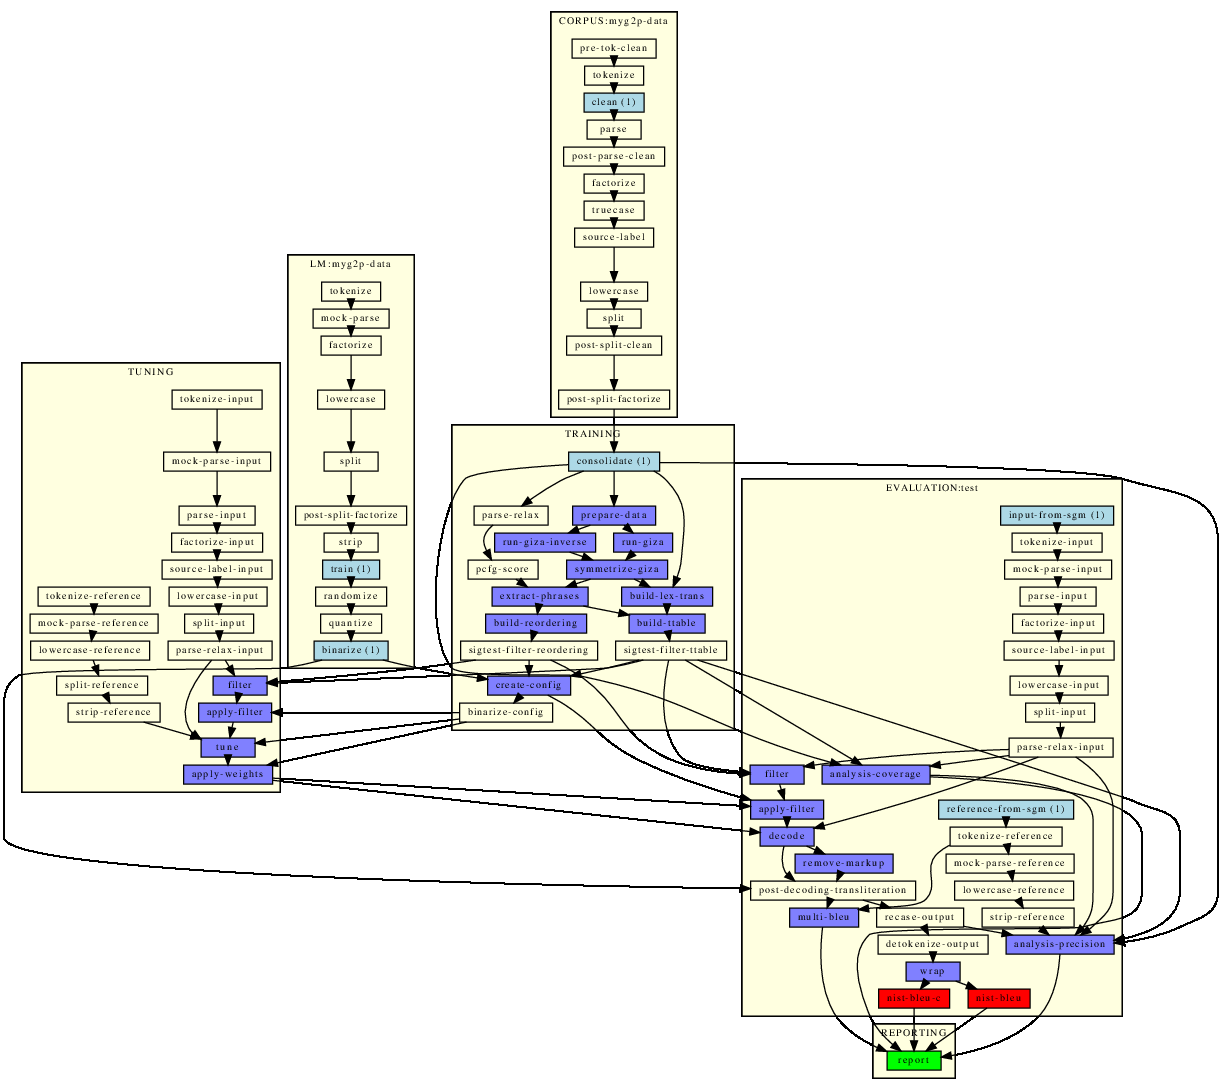

In [37]:
# check graphs
Image(filename=f'{ROOT}/baseline/my-ph/steps/2/graph.2.png', width=800)

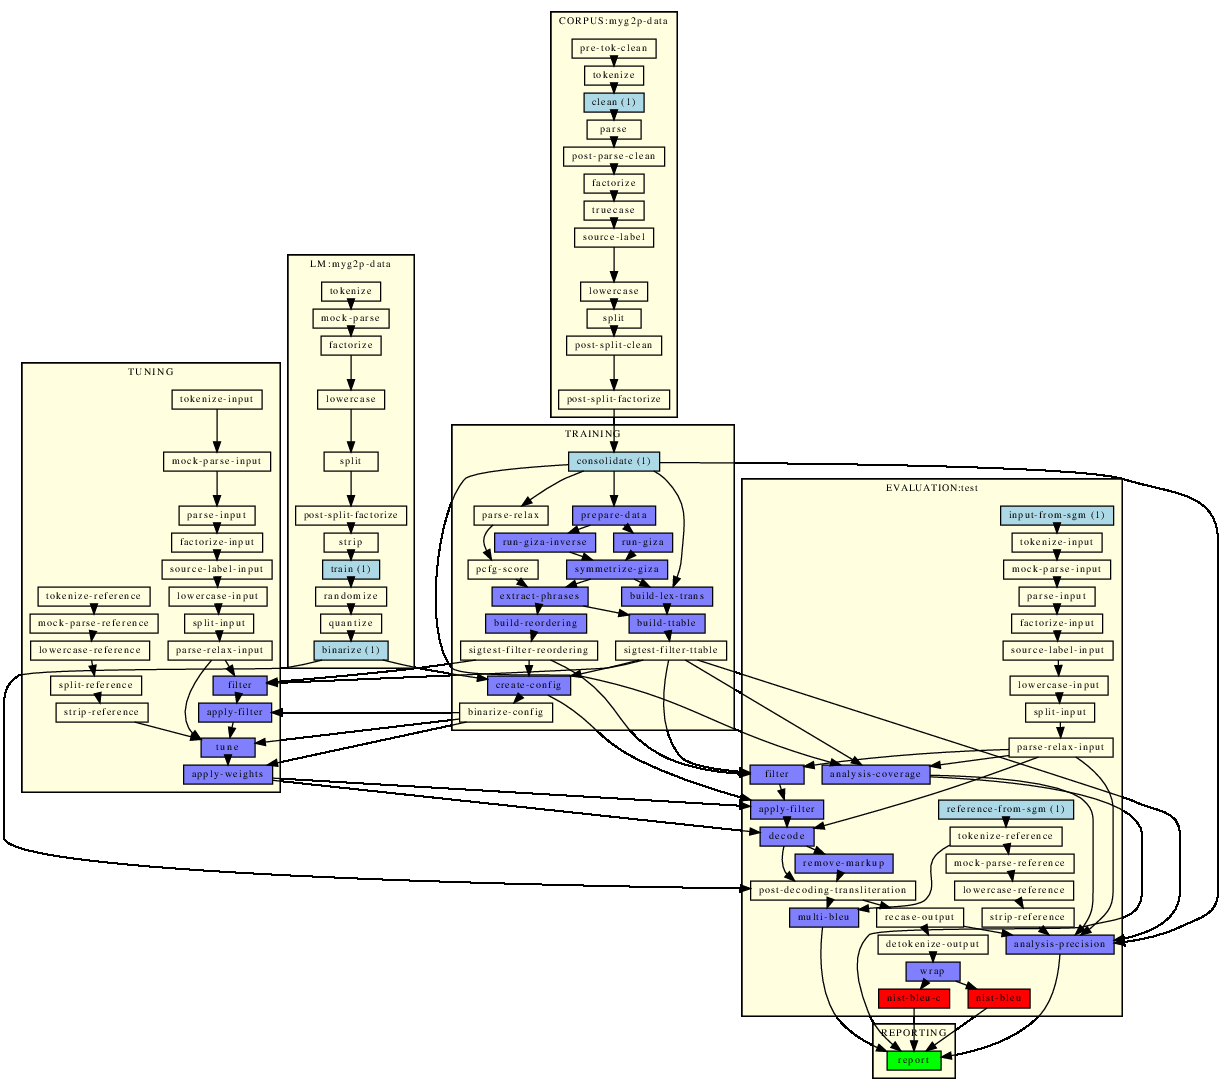

In [38]:
Image(filename=f'{ROOT}/baseline/ph-my/steps/2/graph.2.png', width=800)

## Run 2: Multi-BLEU Score

In [39]:
!find {ROOT}/baseline/my-ph/evaluation -type f -name "*bleu*"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.nist-bleu-c.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation/test.analysis.2/bleu-annotation


In [40]:
!find {ROOT}/baseline/ph-my/evaluation -type f -name "*bleu*"

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.multi-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.nist-bleu.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.nist-bleu-c.2
/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation/test.analysis.2/bleu-annotation


In [41]:
%cd {ROOT}/baseline/my-ph/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation
BLEU = 69.14, 85.2/72.4/64.3/57.6 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [42]:
%cd {ROOT}/baseline/ph-my/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation
BLEU = 78.15, 87.8/79.4/75.0/71.3 (BP=1.000, ratio=1.000, hyp_len=8047, ref_len=8048)
